# 🚗 Car Price Prediction using Machine Learning

**Objective:** Predict the selling price of a used car based on various features like year, fuel type, transmission, kilometers driven, etc.

**Dataset:** Car Price Dataset (301 records, 9 features)

**Libraries Used:** NumPy, Pandas, Matplotlib, Seaborn, Scikit-learn


In [1]:
# ===========================
# 1. IMPORT LIBRARIES
# ===========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Plot settings
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")
sns.set_palette("husl")

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


## 📂 2. Load & Explore the Dataset

In [2]:
# Load dataset
df = pd.read_csv("C:/Users/neelg/Downloads/car data.csv")

print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
df.head()


Shape of dataset: (301, 9)

First 5 rows:


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
# Basic info
print("Dataset Info:")
print("="*50)
df.info()


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Selling_type   301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


In [4]:
# Statistical summary
print("Statistical Summary:")
df.describe()


Statistical Summary:


,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [5]:
# Check for missing values
print("Missing Values in Each Column:")
print("="*40)
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values: {missing.sum()}")


Missing Values in Each Column:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

Total missing values: 0


In [6]:
# Check unique values for categorical columns
cat_cols = ['Fuel_Type', 'Selling_type', 'Transmission', 'Owner']
for col in cat_cols:
    print(f"{col}: {df[col].unique()}")


Fuel_Type: <StringArray>
['Petrol', 'Diesel', 'CNG']
Length: 3, dtype: str
Selling_type: <StringArray>
['Dealer', 'Individual']
Length: 2, dtype: str
Transmission: <StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str
Owner: [0 1 3]


## 📊 3. Exploratory Data Analysis (EDA)

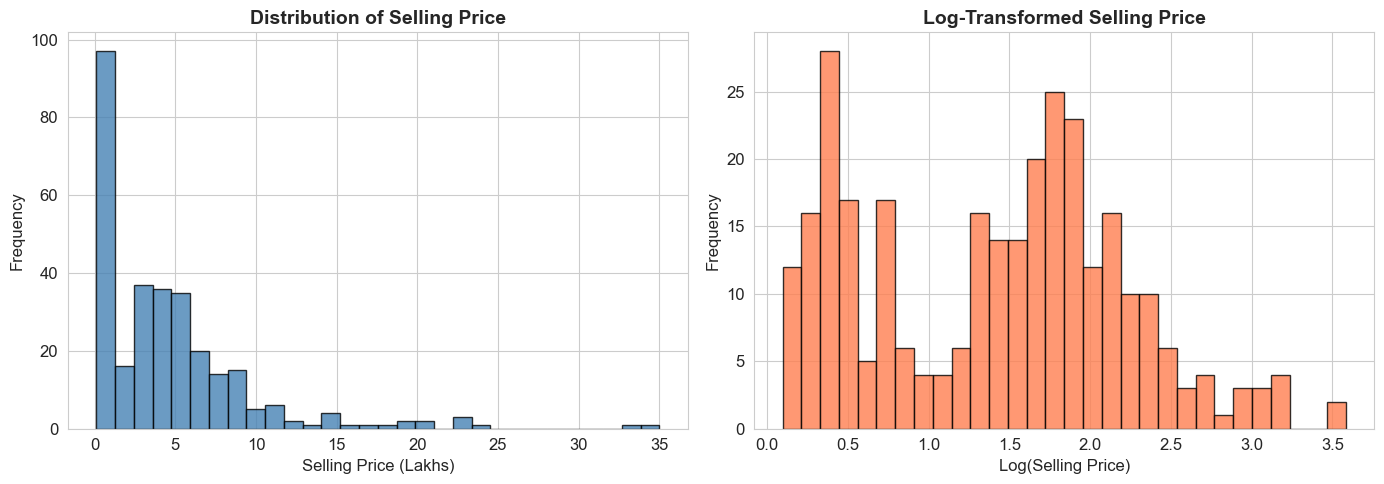

✅ Selling price distribution plotted


In [7]:
# Distribution of Selling Price (Target Variable)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Selling_Price'], bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Distribution of Selling Price', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Selling Price (Lakhs)')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(df['Selling_Price']), bins=30, color='coral', edgecolor='black', alpha=0.8)
axes[1].set_title('Log-Transformed Selling Price', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Log(Selling Price)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('01_selling_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Selling price distribution plotted")


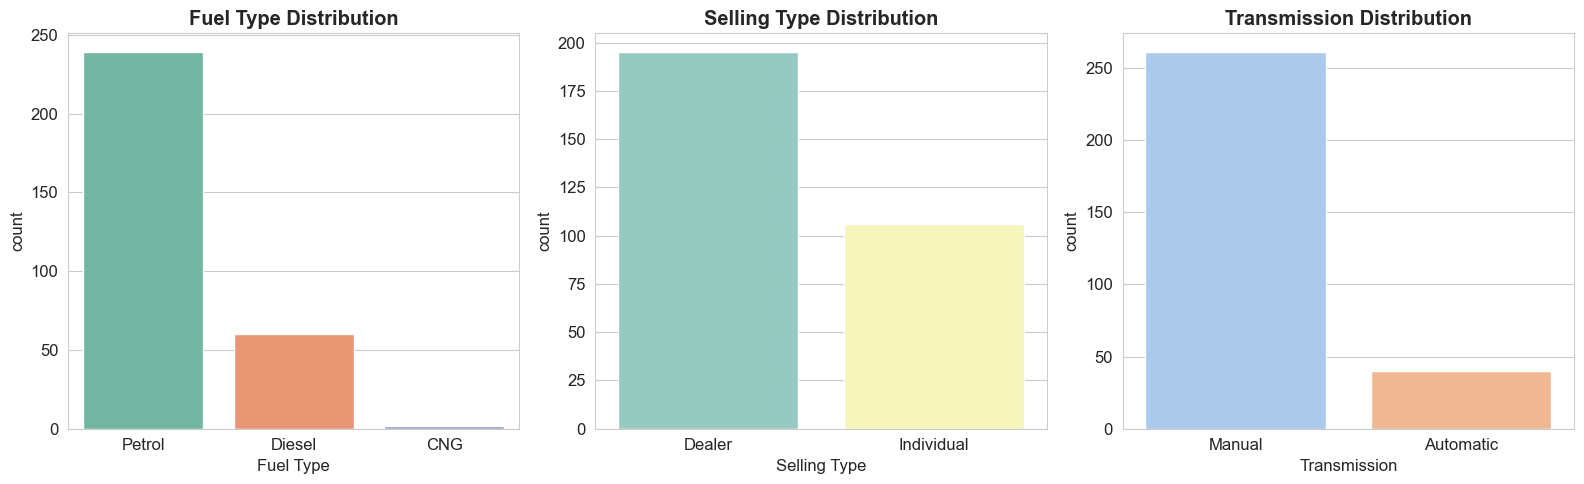

In [8]:
# Count plots for categorical features
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.countplot(data=df, x='Fuel_Type', ax=axes[0], palette='Set2')
axes[0].set_title('Fuel Type Distribution', fontweight='bold')
axes[0].set_xlabel('Fuel Type')

sns.countplot(data=df, x='Selling_type', ax=axes[1], palette='Set3')
axes[1].set_title('Selling Type Distribution', fontweight='bold')
axes[1].set_xlabel('Selling Type')

sns.countplot(data=df, x='Transmission', ax=axes[2], palette='pastel')
axes[2].set_title('Transmission Distribution', fontweight='bold')
axes[2].set_xlabel('Transmission')

plt.tight_layout()
plt.savefig('02_categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


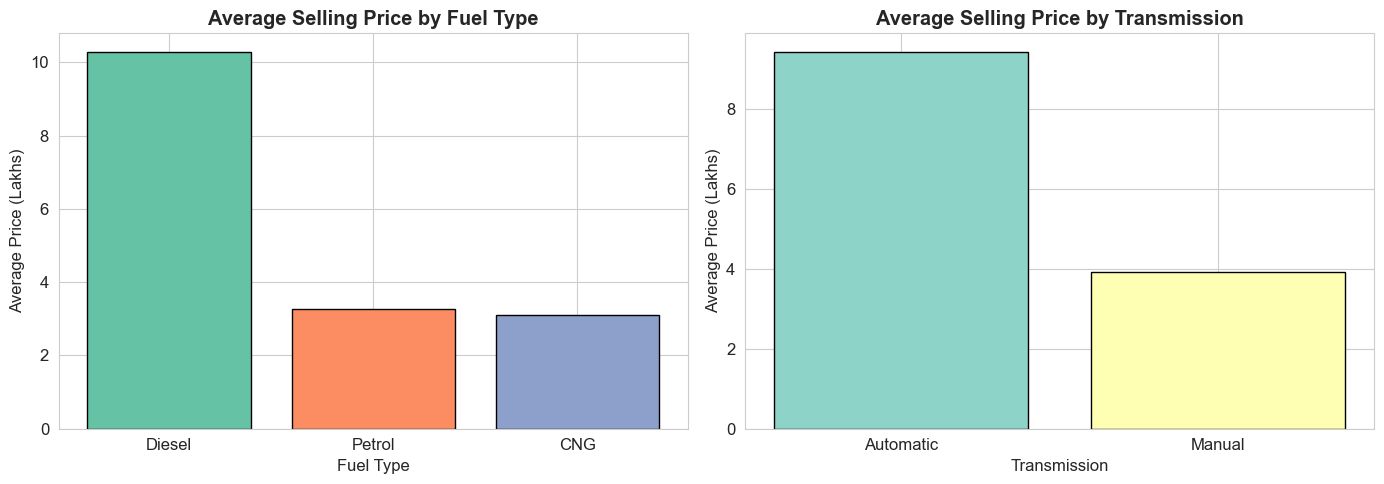

In [9]:
# Average Selling Price by Fuel Type and Transmission
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fuel_avg = df.groupby('Fuel_Type')['Selling_Price'].mean().sort_values(ascending=False)
axes[0].bar(fuel_avg.index, fuel_avg.values, color=sns.color_palette('Set2', len(fuel_avg)), edgecolor='black')
axes[0].set_title('Average Selling Price by Fuel Type', fontweight='bold')
axes[0].set_xlabel('Fuel Type')
axes[0].set_ylabel('Average Price (Lakhs)')

trans_avg = df.groupby('Transmission')['Selling_Price'].mean().sort_values(ascending=False)
axes[1].bar(trans_avg.index, trans_avg.values, color=sns.color_palette('Set3', len(trans_avg)), edgecolor='black')
axes[1].set_title('Average Selling Price by Transmission', fontweight='bold')
axes[1].set_xlabel('Transmission')
axes[1].set_ylabel('Average Price (Lakhs)')

plt.tight_layout()
plt.savefig('03_price_by_category.png', dpi=150, bbox_inches='tight')
plt.show()


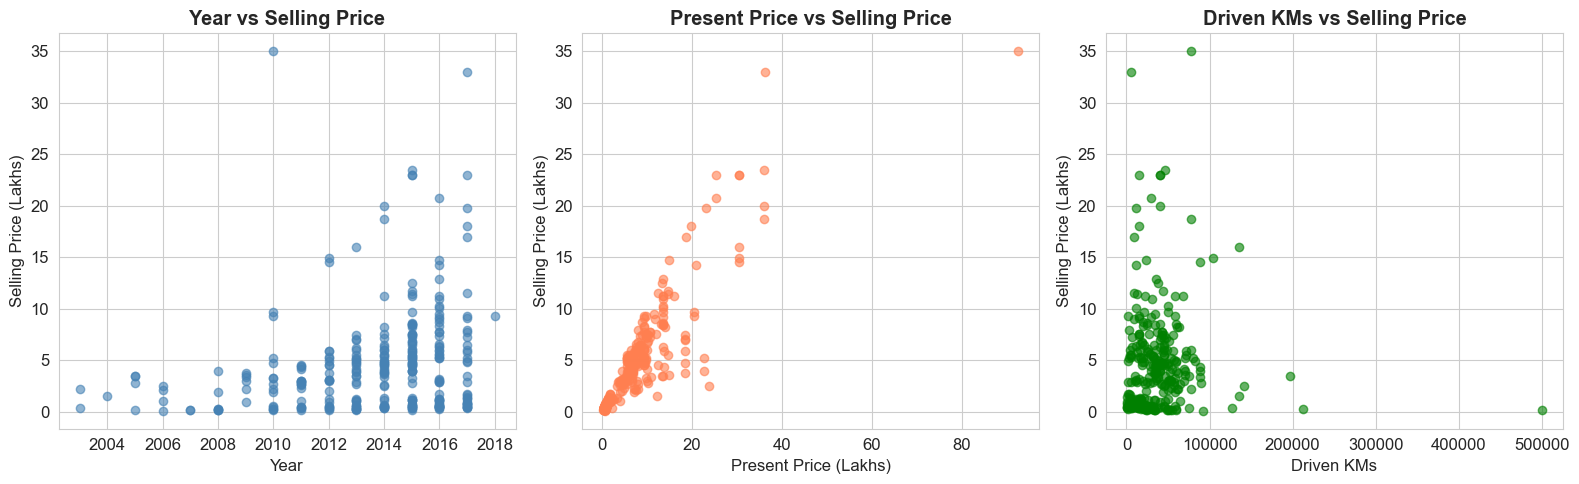

In [10]:
# Scatter plots: Numerical features vs Selling Price
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(df['Year'], df['Selling_Price'], alpha=0.6, color='steelblue')
axes[0].set_title('Year vs Selling Price', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Selling Price (Lakhs)')

axes[1].scatter(df['Present_Price'], df['Selling_Price'], alpha=0.6, color='coral')
axes[1].set_title('Present Price vs Selling Price', fontweight='bold')
axes[1].set_xlabel('Present Price (Lakhs)')
axes[1].set_ylabel('Selling Price (Lakhs)')

axes[2].scatter(df['Driven_kms'], df['Selling_Price'], alpha=0.6, color='green')
axes[2].set_title('Driven KMs vs Selling Price', fontweight='bold')
axes[2].set_xlabel('Driven KMs')
axes[2].set_ylabel('Selling Price (Lakhs)')

plt.tight_layout()
plt.savefig('04_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()


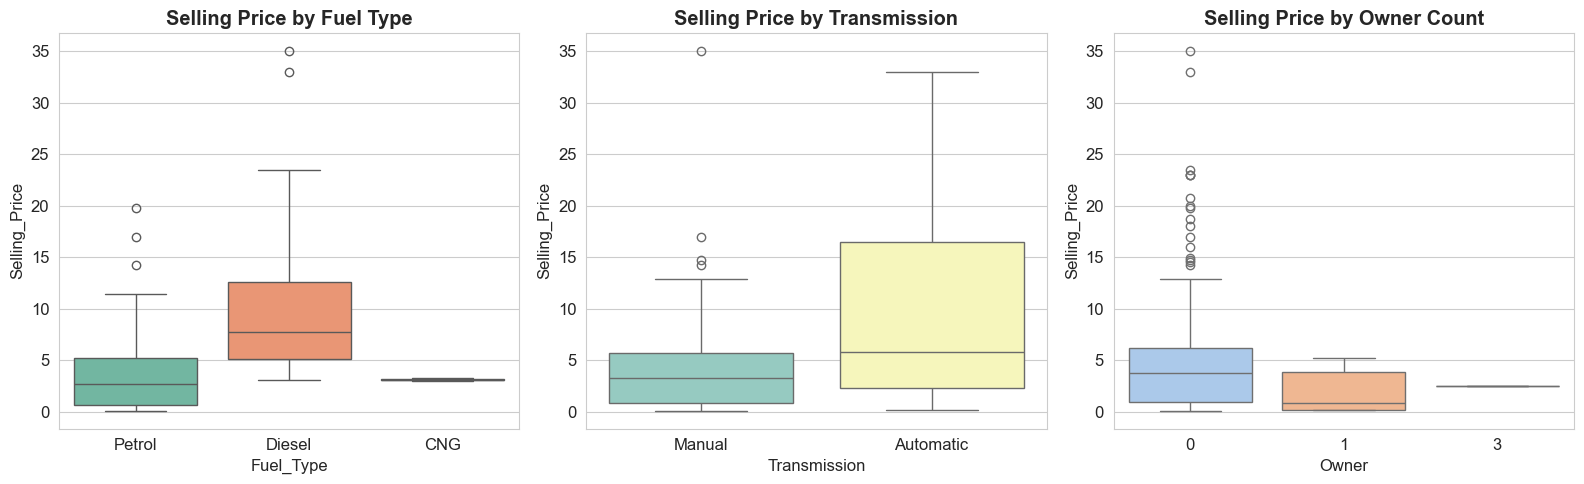

In [11]:
# Box plots: Selling Price vs categorical features
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df, x='Fuel_Type', y='Selling_Price', ax=axes[0], palette='Set2')
axes[0].set_title('Selling Price by Fuel Type', fontweight='bold')

sns.boxplot(data=df, x='Transmission', y='Selling_Price', ax=axes[1], palette='Set3')
axes[1].set_title('Selling Price by Transmission', fontweight='bold')

sns.boxplot(data=df, x='Owner', y='Selling_Price', ax=axes[2], palette='pastel')
axes[2].set_title('Selling Price by Owner Count', fontweight='bold')

plt.tight_layout()
plt.savefig('05_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


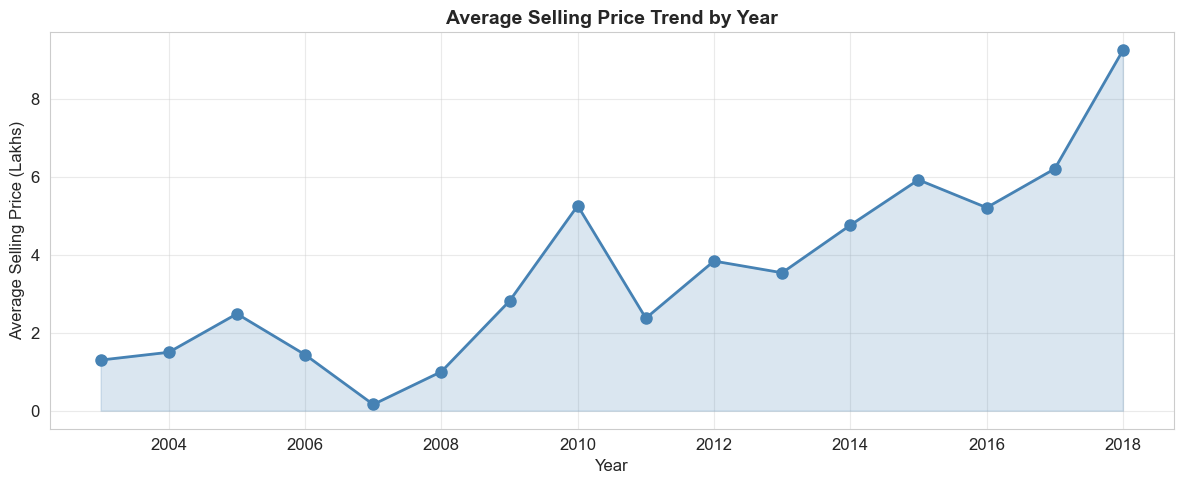

In [12]:
# Year-wise average car price trend
year_avg = df.groupby('Year')['Selling_Price'].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(year_avg['Year'], year_avg['Selling_Price'], marker='o', color='steelblue', linewidth=2, markersize=8)
plt.fill_between(year_avg['Year'], year_avg['Selling_Price'], alpha=0.2, color='steelblue')
plt.title('Average Selling Price Trend by Year', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Average Selling Price (Lakhs)')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('06_year_trend.png', dpi=150, bbox_inches='tight')
plt.show()


## 🔧 4. Feature Engineering & Preprocessing

In [13]:
# Create a copy for preprocessing
data = df.copy()

# Feature: Car Age
data['Car_Age'] = 2024 - data['Year']
print("Sample Car Ages:")
print(data[['Year', 'Car_Age']].head())


Sample Car Ages:
   Year  Car_Age
0  2014       10
1  2013       11
2  2017        7
3  2011       13
4  2014       10


In [14]:
# Drop columns not needed for ML
data.drop(['Car_Name', 'Year'], axis=1, inplace=True)
print("Columns after dropping:", list(data.columns))


Columns after dropping: ['Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Car_Age']


In [15]:
# Label Encoding for categorical variables
le = LabelEncoder()

cat_features = ['Fuel_Type', 'Selling_type', 'Transmission']
for col in cat_features:
    data[col] = le.fit_transform(data[col])
    print(f"{col} encoded.")

print("\nDataset after encoding:")
data.head()


Fuel_Type encoded.
Selling_type encoded.
Transmission encoded.

Dataset after encoding:


,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,2,0,1,0,10
1,4.75,9.54,43000,1,0,1,0,11
2,7.25,9.85,6900,2,0,1,0,7
3,2.85,4.15,5200,2,0,1,0,13
4,4.60,6.87,42450,1,0,1,0,10


## 🔗 5. Correlation Analysis

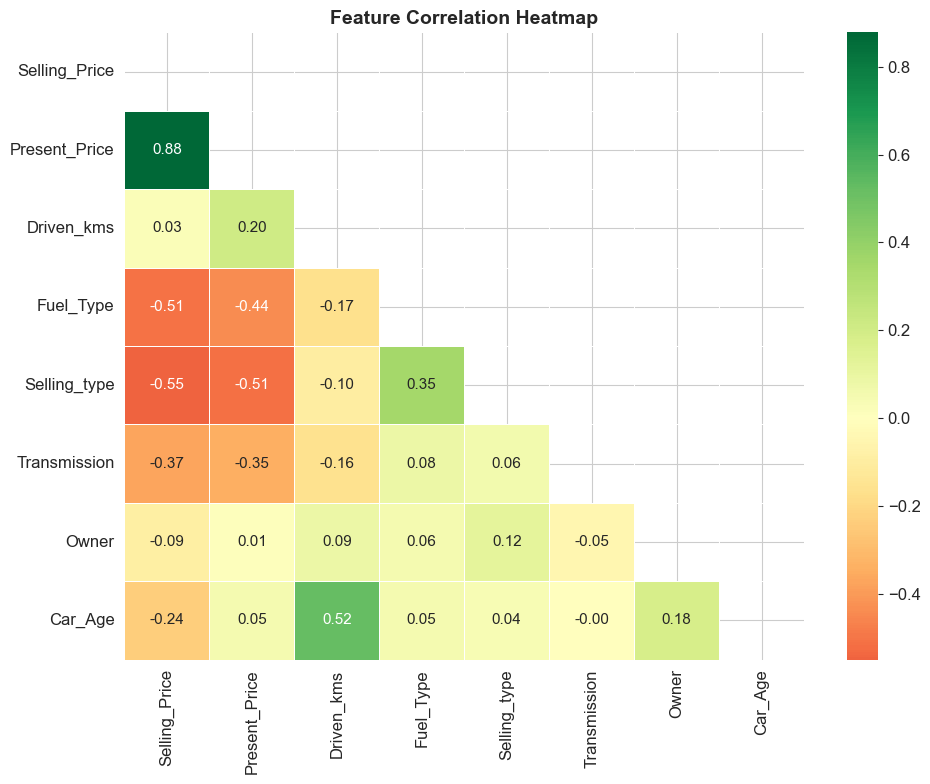


Top correlations with Selling_Price:
Selling_Price    1.000000
Present_Price    0.878914
Driven_kms       0.029187
Owner           -0.088344
Car_Age         -0.236141
Transmission    -0.367128
Fuel_Type       -0.509467
Selling_type    -0.550724
Name: Selling_Price, dtype: float64


In [16]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
corr = data.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, annot_kws={'size': 11})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('07_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nTop correlations with Selling_Price:")
print(corr['Selling_Price'].sort_values(ascending=False))


## 🤖 6. Model Building

In [17]:
# Define Features and Target
X = data.drop('Selling_Price', axis=1)
y = data['Selling_Price']

print("Feature columns:", list(X.columns))
print("Target: Selling_Price")
print("\nX shape:", X.shape)
print("y shape:", y.shape)


Feature columns: ['Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Car_Age']
Target: Selling_Price

X shape: (301, 7)
y shape: (301,)


In [18]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size:  {X_test.shape[0]} samples")


Training set size: 240 samples
Testing set size:  61 samples


In [19]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Feature scaling applied (StandardScaler)")


✅ Feature scaling applied (StandardScaler)


In [20]:
# Helper function: evaluate model
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, scaled=False):
    if scaled:
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        cv_scores = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2')
    else:
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        cv_scores = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2')
    
    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2   = r2_score(y_te, y_pred)
    
    print(f"\n{'='*50}")
    print(f"  Model: {name}")
    print(f"{'='*50}")
    print(f"  MAE  : {mae:.4f} Lakhs")
    print(f"  RMSE : {rmse:.4f} Lakhs")
    print(f"  R²   : {r2:.4f}")
    print(f"  CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'CV_R2': cv_scores.mean(), 'Predictions': y_pred}

results = []


In [21]:
# ---- Model 1: Linear Regression ----
lr = LinearRegression()
res = evaluate_model('Linear Regression', lr, X_train_scaled, y_train, X_test_scaled, y_test)
results.append(res)



  Model: Linear Regression
  MAE  : 1.2219 Lakhs
  RMSE : 1.8792 Lakhs
  R²   : 0.8467
  CV R²: 0.8440 ± 0.0388


In [22]:
# ---- Model 2: Decision Tree ----
dt = DecisionTreeRegressor(random_state=42)
res = evaluate_model('Decision Tree', dt, X_train, y_train, X_test, y_test)
results.append(res)



  Model: Decision Tree
  MAE  : 0.8484 Lakhs
  RMSE : 1.4353 Lakhs
  R²   : 0.9106
  CV R²: 0.8696 ± 0.1078


In [23]:
# ---- Model 3: Random Forest ----
rf = RandomForestRegressor(n_estimators=100, random_state=42)
res = evaluate_model('Random Forest', rf, X_train, y_train, X_test, y_test)
results.append(res)



  Model: Random Forest
  MAE  : 0.6389 Lakhs
  RMSE : 0.9686 Lakhs
  R²   : 0.9593
  CV R²: 0.8832 ± 0.0607


In [24]:
# ---- Model 4: Gradient Boosting ----
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
res = evaluate_model('Gradient Boosting', gb, X_train, y_train, X_test, y_test)
results.append(res)



  Model: Gradient Boosting
  MAE  : 0.5556 Lakhs
  RMSE : 0.8907 Lakhs
  R²   : 0.9656
  CV R²: 0.8855 ± 0.0476


## 📈 7. Model Comparison

In [25]:
# Build comparison dataframe
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'Predictions'} for r in results])
results_df = results_df.sort_values('R2', ascending=False).reset_index(drop=True)
print("Model Performance Comparison:")
results_df


Model Performance Comparison:


,Model,MAE,RMSE,R2,CV_R2
0,Gradient Boosting,0.555563,0.890725,0.965558,0.885513
1,Random Forest,0.638920,0.968647,0.959268,0.883231
2,Decision Tree,0.848361,1.435257,0.910575,0.869638
3,Linear Regression,1.221932,1.879250,0.846690,0.844044


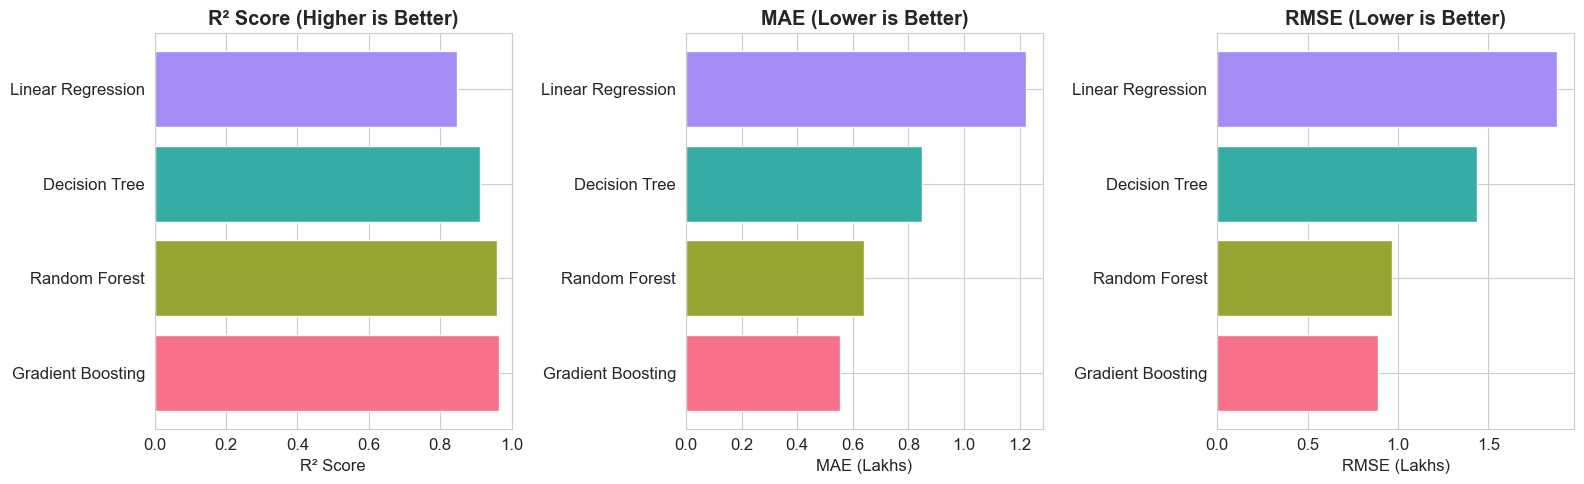

In [26]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = sns.color_palette("husl", len(results_df))

axes[0].barh(results_df['Model'], results_df['R2'], color=colors)
axes[0].set_title('R² Score (Higher is Better)', fontweight='bold')
axes[0].set_xlabel('R² Score')
axes[0].set_xlim(0, 1)

axes[1].barh(results_df['Model'], results_df['MAE'], color=colors)
axes[1].set_title('MAE (Lower is Better)', fontweight='bold')
axes[1].set_xlabel('MAE (Lakhs)')

axes[2].barh(results_df['Model'], results_df['RMSE'], color=colors)
axes[2].set_title('RMSE (Lower is Better)', fontweight='bold')
axes[2].set_xlabel('RMSE (Lakhs)')

plt.tight_layout()
plt.savefig('08_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 🏆 8. Best Model Deep Dive — Random Forest

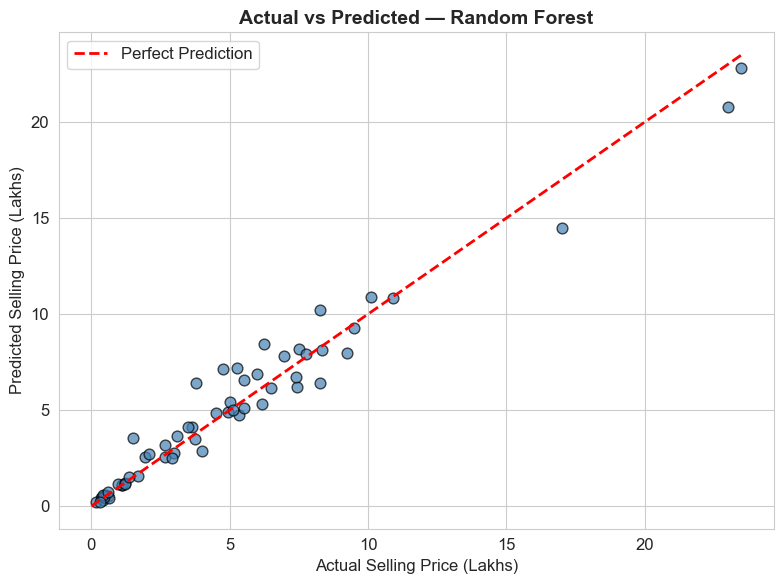

In [27]:
# Actual vs Predicted — Random Forest
rf_preds = [r for r in results if r['Model'] == 'Random Forest'][0]['Predictions']

plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_preds, alpha=0.7, color='steelblue', edgecolors='black', s=60)
max_val = max(y_test.max(), max(rf_preds))
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Selling Price (Lakhs)', fontsize=12)
plt.ylabel('Predicted Selling Price (Lakhs)', fontsize=12)
plt.title('Actual vs Predicted — Random Forest', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('09_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()


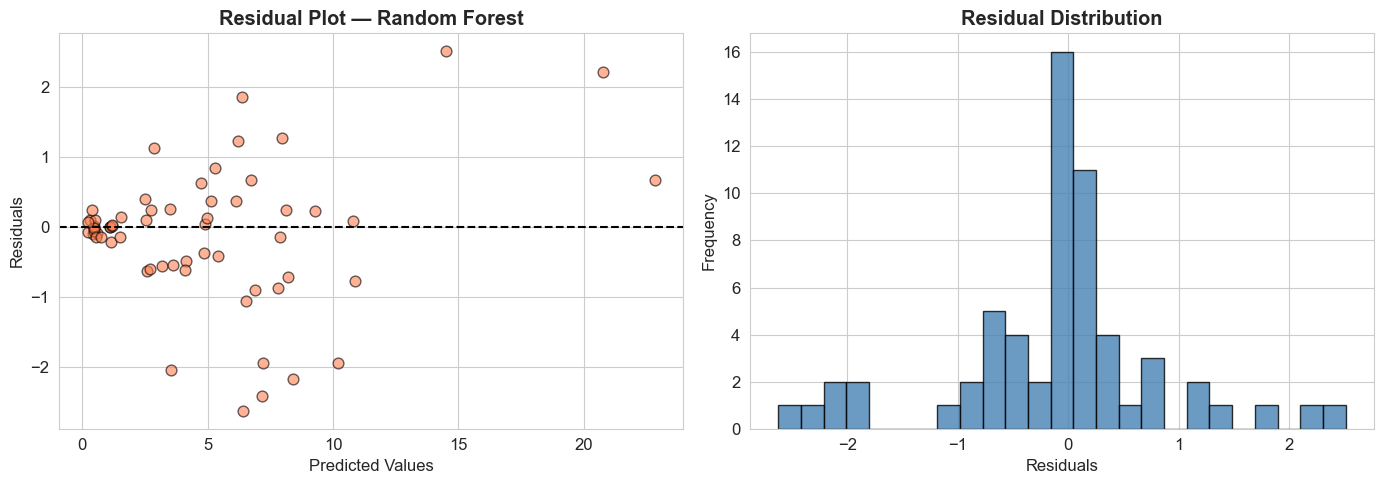

In [28]:
# Residual plot
rf_residuals = y_test.values - rf_preds

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(rf_preds, rf_residuals, alpha=0.6, color='coral', edgecolors='black', s=60)
axes[0].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residual Plot — Random Forest', fontweight='bold')

axes[1].hist(rf_residuals, bins=25, color='steelblue', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig('10_residual_plots.png', dpi=150, bbox_inches='tight')
plt.show()


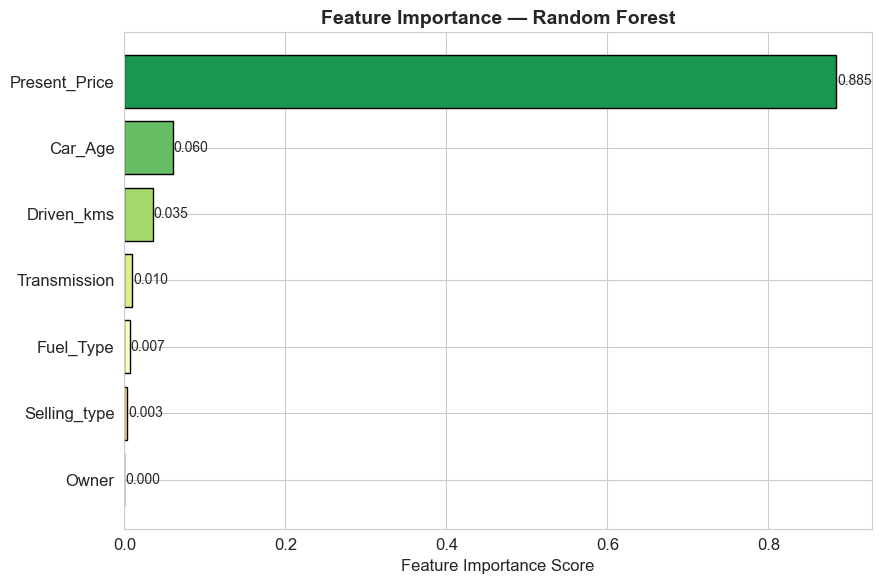


Top Features:
Present_Price    0.884504
Car_Age          0.060462
Driven_kms       0.034973
Transmission     0.009999
Fuel_Type        0.006507
Selling_type     0.003489
Owner            0.000067
dtype: float64


In [29]:
# Feature Importance — Random Forest
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(feat_imp)))
bars = plt.barh(feat_imp.index, feat_imp.values, color=colors, edgecolor='black')
plt.xlabel('Feature Importance Score')
plt.title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')

for bar, val in zip(bars, feat_imp.values):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('11_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop Features:")
print(feat_imp.sort_values(ascending=False))


## ⚙️ 9. Hyperparameter Tuning (Random Forest)

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print("\n✅ Grid Search Complete!")
print("Best Parameters:", grid_search.best_params_)
print("Best CV R²:", round(grid_search.best_score_, 4))


Fitting 5 folds for each of 18 candidates, totalling 90 fits


In [ ]:
# Evaluate tuned model
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)

print("\n📊 Tuned Random Forest Performance:")
print(f"  MAE  : {mean_absolute_error(y_test, y_pred_tuned):.4f} Lakhs")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_tuned)):.4f} Lakhs")
print(f"  R²   : {r2_score(y_test, y_pred_tuned):.4f}")



📊 Tuned Random Forest Performance:
  MAE  : 0.6389 Lakhs
  RMSE : 0.9686 Lakhs
  R²   : 0.9593


## 🔮 10. Predict Price of a New Car

In [ ]:
# Sample prediction
# Features: Present_Price, Driven_kms, Fuel_Type, Selling_type, Transmission, Owner, Car_Age
# Fuel_Type: CNG=0, Diesel=1, Petrol=2 | Selling_type: Dealer=0, Individual=1 | Transmission: Automatic=0, Manual=1

sample_car = pd.DataFrame([{
    'Present_Price': 8.5,
    'Driven_kms': 30000,
    'Fuel_Type': 2,         # Petrol
    'Selling_type': 0,      # Dealer
    'Transmission': 1,      # Manual
    'Owner': 0,
    'Car_Age': 6            # 2018 car
}])

predicted_price = best_rf.predict(sample_car)[0]
print("=" * 45)
print("  🚗 Sample Car Details")
print("=" * 45)
print(f"  Present Price : ₹8.5 Lakhs")
print(f"  Driven KMs    : 30,000")
print(f"  Fuel Type     : Petrol")
print(f"  Seller        : Dealer")
print(f"  Transmission  : Manual")
print(f"  Previous Owner: 0")
print(f"  Car Age       : 6 Years")
print("=" * 45)
print(f"  💰 Predicted Selling Price: ₹{predicted_price:.2f} Lakhs")
print("=" * 45)


  🚗 Sample Car Details
  Present Price : ₹8.5 Lakhs
  Driven KMs    : 30,000
  Fuel Type     : Petrol
  Seller        : Dealer
  Transmission  : Manual
  Previous Owner: 0
  Car Age       : 6 Years
  💰 Predicted Selling Price: ₹6.74 Lakhs


## 📝 11. Summary & Conclusions

In [ ]:
print("=" * 60)
print("       CAR PRICE PREDICTION — PROJECT SUMMARY")
print("=" * 60)
print(f"\n📦 Dataset      : 301 cars, 9 features")
print(f"🎯 Target       : Selling Price (₹ Lakhs)")
print()
print("📊 Models Trained & Evaluated:")
for _, row in results_df.iterrows():
    print(f"   {row['Model']:<22} R²={row['R2']:.4f}  MAE={row['MAE']:.4f}  RMSE={row['RMSE']:.4f}")
print()
print("🏆 Best Model   : Random Forest Regressor")
print(f"   R² Score     : {results_df[results_df['Model']=='Random Forest']['R2'].values[0]:.4f}")
print()
print("🔑 Key Findings:")
print("   • Present_Price & Car_Age are the strongest predictors")
print("   • Automatic transmission cars fetch higher prices")
print("   • Diesel cars have higher resale value on average")
print("   • More previous owners → lower selling price")
print("   • Fewer driven KMs → higher resale value")
print("=" * 60)


       CAR PRICE PREDICTION — PROJECT SUMMARY

📦 Dataset      : 301 cars, 9 features
🎯 Target       : Selling Price (₹ Lakhs)

📊 Models Trained & Evaluated:
   Gradient Boosting      R²=0.9656  MAE=0.5556  RMSE=0.8907
   Random Forest          R²=0.9593  MAE=0.6389  RMSE=0.9686
   Decision Tree          R²=0.9106  MAE=0.8484  RMSE=1.4353
   Linear Regression      R²=0.8467  MAE=1.2219  RMSE=1.8792

🏆 Best Model   : Random Forest Regressor
   R² Score     : 0.9593

🔑 Key Findings:
   • Present_Price & Car_Age are the strongest predictors
   • Automatic transmission cars fetch higher prices
   • Diesel cars have higher resale value on average
   • More previous owners → lower selling price
   • Fewer driven KMs → higher resale value
